In [1]:
!pwd

/truejit/evaluation/llvm-versions-comparison/plot


In [2]:
import glob
import json
import pandas as pd

versions = range(9, 19)
dates = ['2019-12-11', '2020-07-07', '2021-02-03', '2021-06-28', '2022-01-20', '2022-06-22', '2023-01-11', '2023-06-10',
         '2023-11-28', '2024-04-16']


def parse_sequences():
    sequences = []
    for file in sorted(glob.glob('../trace/sequences/*.json')):
        with open(file) as f:
            sequence = json.load(f)
            file_name = file.split('/')[-1]
            name = file_name.split('.')[0]
            sequences.append((name, sequence))
    sorted(sequences, key=lambda x: x[0])
    names = [name for name, _ in sequences]
    sequences = [sequence for _, sequence in sequences]
    return sequences


In [3]:
sequences = parse_sequences()
df = pd.DataFrame([(version, date, len(sequence)) for version, date, sequence in zip(versions, dates, sequences)],
                  columns=['Version', 'Date', 'Length'])
df

,Version,Date,Length
0,9,2019-12-11,11588
1,10,2020-07-07,11918
2,11,2021-02-03,12603
3,12,2021-06-28,13090
4,13,2022-01-20,12674
5,14,2022-06-22,13012
6,15,2023-01-11,13263
7,16,2023-06-10,13564
8,17,2023-11-28,13843
9,18,2024-04-16,14080


In [4]:
import difflib
import numpy as np

sequences = parse_sequences()
similarity_matrix = np.zeros((len(sequences), len(sequences)))
for i in range(len(sequences)):
    for j in range(len(sequences)):
        similarity_matrix[i, j] = difflib.SequenceMatcher(None, sequences[i], sequences[j]).ratio()
similarity_matrix


array([[1.        , 0.91797839, 0.83568269, 0.75929978, 0.52015497,
        0.39382114, 0.37720816, 0.3649014 , 0.42774566, 0.41343307],
       [0.91814856, 1.        , 0.89107296, 0.79694498, 0.63980156,
        0.5016446 , 0.47956793, 0.38278   , 0.44641124, 0.43103316],
       [0.83551734, 0.89221484, 1.        , 0.87712607, 0.69604779,
        0.53765372, 0.51743602, 0.50231207, 0.48113136, 0.46583967],
       [0.75897561, 0.79798464, 0.87712607, 1.        , 0.76556435,
        0.56179603, 0.53496756, 0.51969686, 0.49805072, 0.48295915],
       [0.52320501, 0.64386792, 0.69612691, 0.76564198, 1.        ,
        0.65171689, 0.61394918, 0.59463374, 0.56386469, 0.53905958],
       [0.39365854, 0.50204573, 0.53788796, 0.56225577, 0.65140543,
        1.        , 0.90085633, 0.85821794, 0.79538261, 0.75372804],
       [0.37777152, 0.48052103, 0.51565762, 0.53307024, 0.61379496,
        0.89986679, 1.        , 0.93234428, 0.85442337, 0.80612954],
       [0.36569656, 0.38301546, 0.5025413

In [3]:
def create_vocab(sequences):
    vocab = set([word for sequence in sequences for word in sequence])
    vocab = sorted(vocab)
    word_to_idx = {word: i for i, word in enumerate(vocab)}
    idx_to_word = {i: word for i, word in enumerate(vocab)}
    return vocab, word_to_idx, idx_to_word

In [4]:
import torch

# Check for GPU availability and set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

In [8]:
import torch.optim as optim
import torch.nn as nn


# The LSTM model
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, output_size):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = x.clamp(0, self.embedding.num_embeddings - 1)
        embeds = self.embedding(x)
        lstm_out, _ = self.lstm(embeds)
        output = self.fc(lstm_out[:, -1, :])
        return output


sequences = parse_sequences()

# parse dataset
training_datasets = sequences[:-1]
validation_datasets = [sequences[-1]]

vocab, word_to_idx, idx_to_word = create_vocab(training_datasets)

# convert dataset to indices
training_datasets = [[word_to_idx[word] for word in dataset] for dataset in training_datasets]
validation_datasets = [[word_to_idx.get(word, -1) for word in dataset] for dataset in validation_datasets]

window_size = 3


def prepare_data(dataset, window_size=3):
    X = []
    y = []

    for dataset in training_datasets:
        if len(dataset) == 0:
            continue

        # [0, 0, ..., 0, 1] -> [2]
        # [0, 0, ..., 1, 2] -> [3]
        # ...
        X += [[0] * (window_size - i - 1) + dataset[:i + 1] for i in range(window_size - 1)]
        y += dataset[1:window_size]

        # [1, 2, ..., k] -> [k+1]
        # ...
        X += [dataset[i - window_size:i] for i in range(window_size, len(dataset))]
        y += dataset[window_size:]

    # convert to tensors and move to device
    X = torch.tensor(X, dtype=torch.long)
    y = torch.tensor(y, dtype=torch.long)

    return X, y


X_train, y_train = prepare_data(training_datasets)
X_valid, y_valid = prepare_data(validation_datasets)

# use dataloader
train_loader = torch.utils.data.DataLoader(list(zip(X_train, y_train)), batch_size=32 ** 3, shuffle=True)
valid_loader = torch.utils.data.DataLoader(list(zip(X_valid, y_valid)), batch_size=32 ** 3, shuffle=False)

# Parameters
embed_size = 32
hidden_size = 64
vocab_size = len(vocab)
output_size = vocab_size

# Instantiate the model, move it to device, setup loss function and optimizer
model = LSTMModel(vocab_size, embed_size, hidden_size, output_size).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Training loop use dataloader
epochs = 10000
for epoch in range(epochs):
    model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch.to(device))
        loss = criterion(output, y_batch.to(device))
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item()}")

# validate the model
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for X_batch, y_batch in valid_loader:
        output = model(X_batch.to(device))
        predicted = torch.argmax(output, dim=1)
        correct += (predicted == y_batch.to(device)).sum().item()
        total += y_batch.size(0)

print(f"Accuracy: {correct / total}")
# Accuracy: 0.9266326698470143

# Epoch 5000/5000, Loss: 0.1426382064819336
# Accuracy: 0.9266625790725149


# Epoch 1000/1000, Loss: 0.1687786728143692
# Accuracy: 0.9188375192564

# batch_size = 32**2
# lr = 0.001
# epochs = 2000
# Epoch 2000/2000, Loss: 0.183586984872818
# Accuracy: 0.9186038460872726

# batch_size = 32**3
# lr = 0.0001
# epochs = 1000

In [7]:
# snapshot the model
# Epoch 1000/1000, Loss: 1.361098289489746
# Accuracy: 0.8423831201426272
torch.save(model.state_dict(), 'out/model.a92.pth')

# Epoch 10000/10000, Loss: 0.15507517755031586
# Accuracy: 0.9188548283800391

In [5]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

sequences = parse_sequences()


# The LSTM model
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, output_size):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = x.clamp(0, self.embedding.num_embeddings - 1)
        embeds = self.embedding(x)
        lstm_out, _ = self.lstm(embeds)
        output = self.fc(lstm_out[:, -1, :])
        return output


# Check for GPU availability and set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

accuracy_matrix = np.zeros((len(sequences), len(sequences)))
for i in range(len(sequences)):
    # parse dataset
    training_datasets = [sequences[i]]

    # create vocabulary
    vocab = set([word for dataset in training_datasets for word in dataset])
    vocab = sorted(vocab)

    # create word to index and index to word mappings
    word_to_idx = {word: i for i, word in enumerate(vocab)}
    idx_to_word = {i: word for i, word in enumerate(vocab)}

    # convert dataset to indices
    training_datasets = [[word_to_idx[word] for word in dataset] for dataset in training_datasets]

    window_size = 3

    X_train = []
    y_train = []

    for dataset in training_datasets:
        if len(dataset) == 0:
            continue

        # [0, 0, ..., 0, 1] -> [2]
        # [0, 0, ..., 1, 2] -> [3]
        # ...
        X_train += [[0] * (window_size - i - 1) + dataset[:i + 1] for i in range(window_size - 1)]
        y_train += dataset[1:window_size]

        # [1, 2, ..., k] -> [k+1]
        # ...
        X_train += [dataset[i - window_size:i] for i in range(window_size, len(dataset))]
        y_train += dataset[window_size:]

    # convert to tensors and move to device
    X_train = torch.tensor(X_train, dtype=torch.long).to(device)
    y_train = torch.tensor(y_train, dtype=torch.long).to(device)

    # use dataloader

    # Parameters
    embed_size = 32
    hidden_size = 64
    vocab_size = len(vocab)
    output_size = vocab_size

    # Instantiate the model, move it to device
    model = LSTMModel(vocab_size, embed_size, hidden_size, output_size).to(device)
    # if model f'out/model.{opt}.pth' exists, load it
    if os.path.exists(f'out/model.{i}.pth'):
        model.load_state_dict(torch.load(f'out/model.{i}.pth'))
    else:
        # setup loss function and optimizer
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.01)
        # Training loop
        epochs = 1000
        for epoch in range(epochs):
            model.train()
            optimizer.zero_grad()
            output = model(X_train)
            loss = criterion(output, y_train)
            loss.backward()
            optimizer.step()

            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.15f}")
        # save the model
        torch.save(model.state_dict(), f'out/model.{i}.pth')
    for j in range(len(sequences)):
        # convert dataset to indices
        validation_datasets = [sequences[j]]
        validation_datasets = [[word_to_idx.get(word, -1) for word in dataset] for dataset in validation_datasets]

        validX = []
        validY = []

        for dataset in validation_datasets:
            if len(dataset) == 0:
                continue

            # [0, 0, ..., 0, 1] -> [2]
            # [0, 0, ..., 1, 2] -> [3]
            # ...
            validX += [[0] * (window_size - i - 1) + dataset[:i + 1] for i in range(window_size - 1)]
            validY += dataset[1:window_size]

            # [1, 2, ..., k] -> [k+1]
            # ...
            validX += [dataset[i - window_size:i] for i in range(window_size, len(dataset))]
            validY += dataset[window_size:]

        # convert to tensors and move to device
        validX = torch.tensor(validX, dtype=torch.long).to(device)
        validY = torch.tensor(validY, dtype=torch.long).to(device)

        # validate the model
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for ii in range(len(validX)):
                output = model(validX[ii].unsqueeze(0))
                predicted = torch.argmax(output, dim=1).item()
                actual = validY[ii].item()
                if predicted == actual:
                    correct += 1
                total += 1
        accuracy_matrix[i, j] = correct / total
        print(f"{accuracy_matrix[i, j]:.2f}", end=' ')
    print()

In [12]:
# Using cuda
# Epoch 1000/1000, Loss: 0.00032271811505779624
# 1.00 0.79 0.63 0.51 0.36 0.33 0.30 0.28 0.25 0.23 
# Epoch 1000/1000, Loss: 0.00032606389140710235
# 0.81 1.00 0.74 0.57 0.40 0.37 0.33 0.30 0.27 0.25

# Epoch 1000/1000, Loss: 0.000320891645969823
# 1.00 0.79 0.64 0.51 0.36 0.33 0.29 0.27 0.25 0.23 
# Epoch 1000/1000, Loss: 0.00032199648558162153
# 0.82 1.00 0.75 0.59 0.41 0.37 0.34 0.31 0.28 0.26

In [54]:
import json
import matplotlib.pyplot as plt
import scipy.stats.mstats
import numpy as np

# font
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
})

In [55]:
import numpy as np

accuracy_matrix = np.array([
    [1.00, 0.81, 0.65, 0.54, 0.39, 0.35, 0.32, 0.30, 0.27, 0.25],
    [0.84, 1.00, 0.77, 0.61, 0.45, 0.41, 0.37, 0.34, 0.31, 0.29],
    [0.71, 0.80, 1.00, 0.75, 0.53, 0.48, 0.43, 0.40, 0.35, 0.33],
    [0.61, 0.67, 0.78, 1.00, 0.64, 0.56, 0.50, 0.46, 0.41, 0.38],
    [0.43, 0.47, 0.53, 0.62, 1.00, 0.79, 0.67, 0.61, 0.52, 0.48],
    [0.40, 0.43, 0.49, 0.55, 0.81, 1.00, 0.78, 0.69, 0.59, 0.53],
    [0.36, 0.39, 0.44, 0.49, 0.70, 0.80, 1.00, 0.83, 0.69, 0.61],
    [0.35, 0.38, 0.42, 0.47, 0.65, 0.73, 0.86, 1.00, 0.79, 0.68],
    [0.33, 0.35, 0.39, 0.43, 0.57, 0.64, 0.72, 0.81, 1.00, 0.82],
    [0.31, 0.33, 0.37, 0.40, 0.53, 0.58, 0.65, 0.72, 0.83, 1.00]
])

similarity_matrix = np.array([
    [1.00, 0.92, 0.84, 0.76, 0.52, 0.39, 0.38, 0.36, 0.43, 0.41],
    [0.92, 1.00, 0.89, 0.80, 0.64, 0.50, 0.48, 0.38, 0.45, 0.43],
    [0.84, 0.89, 1.00, 0.88, 0.70, 0.54, 0.52, 0.50, 0.48, 0.47],
    [0.76, 0.80, 0.88, 1.00, 0.77, 0.56, 0.53, 0.52, 0.50, 0.48],
    [0.52, 0.64, 0.70, 0.77, 1.00, 0.65, 0.61, 0.59, 0.56, 0.54],
    [0.39, 0.50, 0.54, 0.56, 0.65, 1.00, 0.90, 0.86, 0.80, 0.75],
    [0.38, 0.48, 0.52, 0.53, 0.61, 0.90, 1.00, 0.93, 0.85, 0.81],
    [0.36, 0.38, 0.50, 0.52, 0.60, 0.86, 0.93, 1.00, 0.91, 0.85],
    [0.43, 0.45, 0.48, 0.50, 0.56, 0.80, 0.86, 0.91, 1.00, 0.92],
    [0.41, 0.43, 0.47, 0.48, 0.54, 0.75, 0.81, 0.85, 0.92, 1.00]
])

versions = [9, 10, 11, 12, 13, 14, 15, 16, 17, 18]

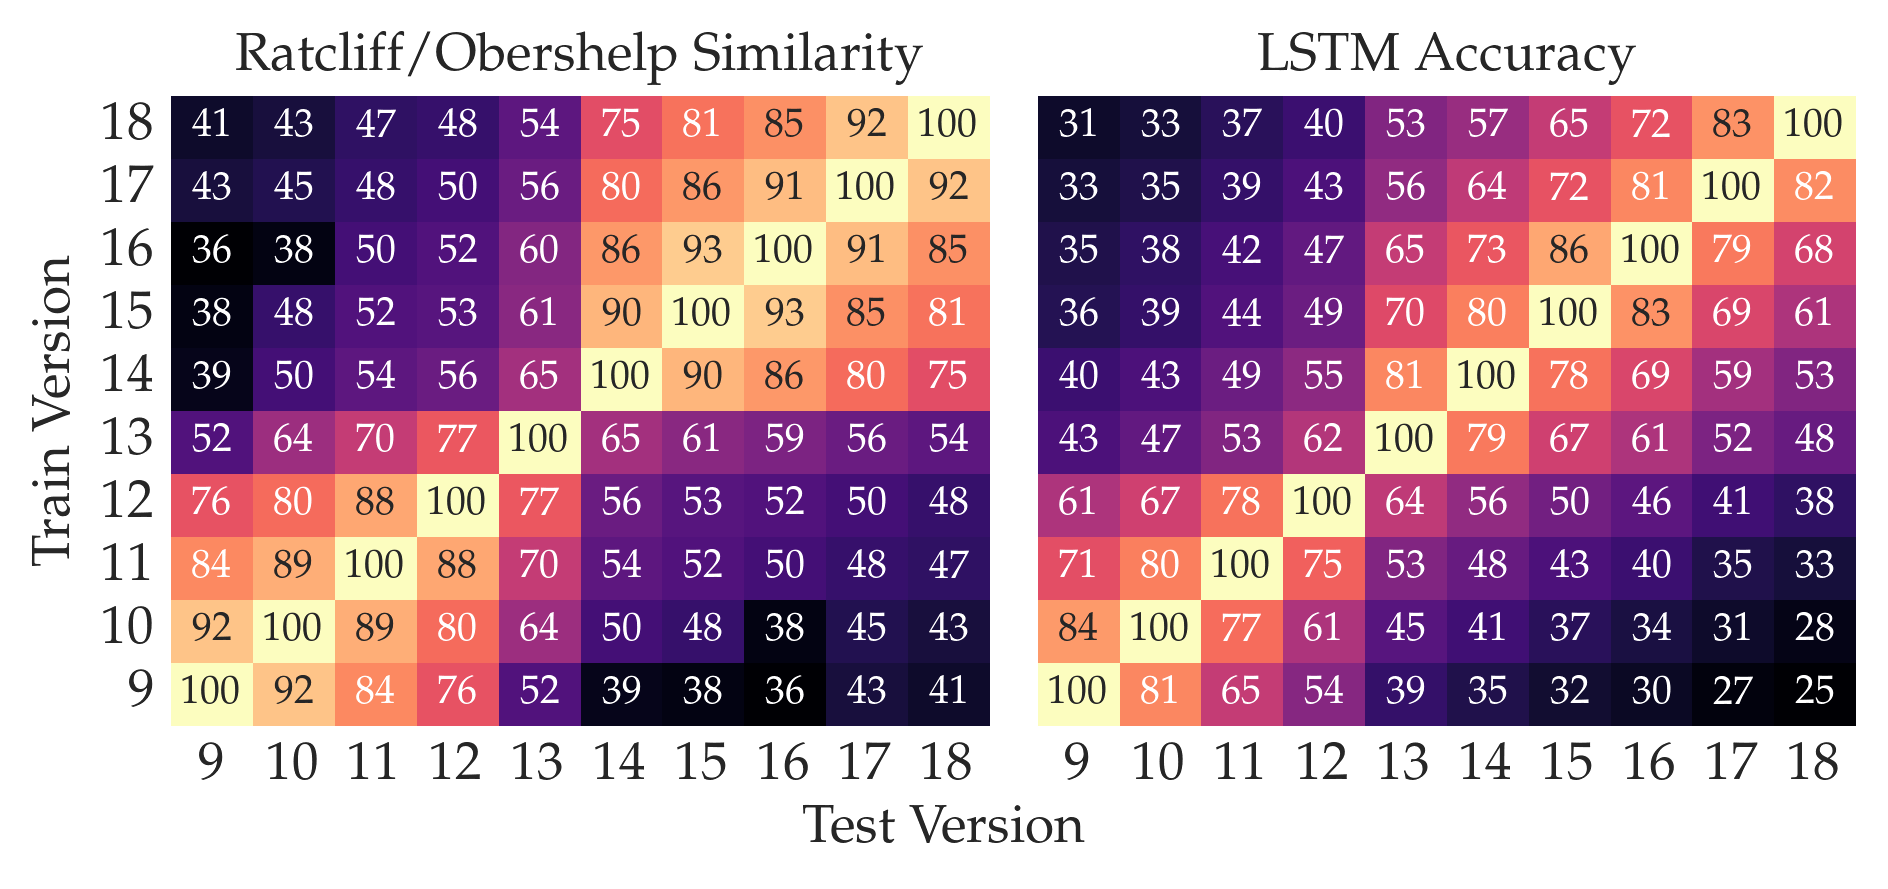

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create two subplots side-by-side, sharing the y-axis
fig, axes = plt.subplots(1, 2, figsize=(6, 3), dpi=320, sharey=True) # Increased figsize for labels

# Flip the matrices to plot with the y-axis increasing from bottom to top
# Also scale to 0-100 and convert to integers for annotation
flipped_sim_scaled = np.flipud((similarity_matrix * 100).astype(int))
flipped_acc_scaled = np.flipud((accuracy_matrix * 100).astype(int))


# Define font sizes
annot_size = 9


# Plot Similarity Matrix using seaborn
sns.heatmap(flipped_sim_scaled, ax=axes[0], xticklabels=versions, cbar=False, cmap='magma',
            annot=True, fmt='d',
            annot_kws={"size": annot_size}
            # linewidths=.5, linecolor='black'
            ) # Added annot and fmt
axes[0].set_title('Ratcliff/Obershelp Similarity', fontsize=12)
axes[0].set_ylabel('Train Version', fontsize=12)

# Plot Accuracy Matrix using seaborn
sns.heatmap(flipped_acc_scaled, ax=axes[1], xticklabels=versions, cbar=False, cmap='magma',
            annot=True, fmt='d',
            annot_kws={"size": annot_size}
            # linewidths=.5, linecolor='black'
            ) # Added annot and fmt
axes[1].set_title('LSTM Accuracy', fontsize=12)

# Set a single, centered x-axis label for the entire figure
fig.supxlabel('Test Version', y=.09, fontsize=12)

# Manually set the y-tick labels on the first plot to ensure they are visible.
# The labels must be reversed to match the flipped data.
reversed_versions = versions[::-1]
tick_locations = np.arange(len(versions)) + 0.5
axes[0].set_yticks(tick_locations)
axes[0].set_yticklabels(reversed_versions, fontsize=12)
axes[0].tick_params(axis='y', rotation=0)

# set x-axis font size
for tick in axes[0].get_xticklabels():
    tick.set_fontsize(12)
for tick in axes[1].get_xticklabels():
    tick.set_fontsize(12)

# remove the tick lines on the y-axis
axes[0].tick_params(axis='both', which='both', length=0)
axes[1].tick_params(axis='both', which='both', length=0)

plt.tight_layout()
plt.savefig(f'./out/similarity-accuracy-matrix.pdf', bbox_inches='tight', pad_inches=0.01, dpi=320, transparent=True, format='pdf')
plt.show()

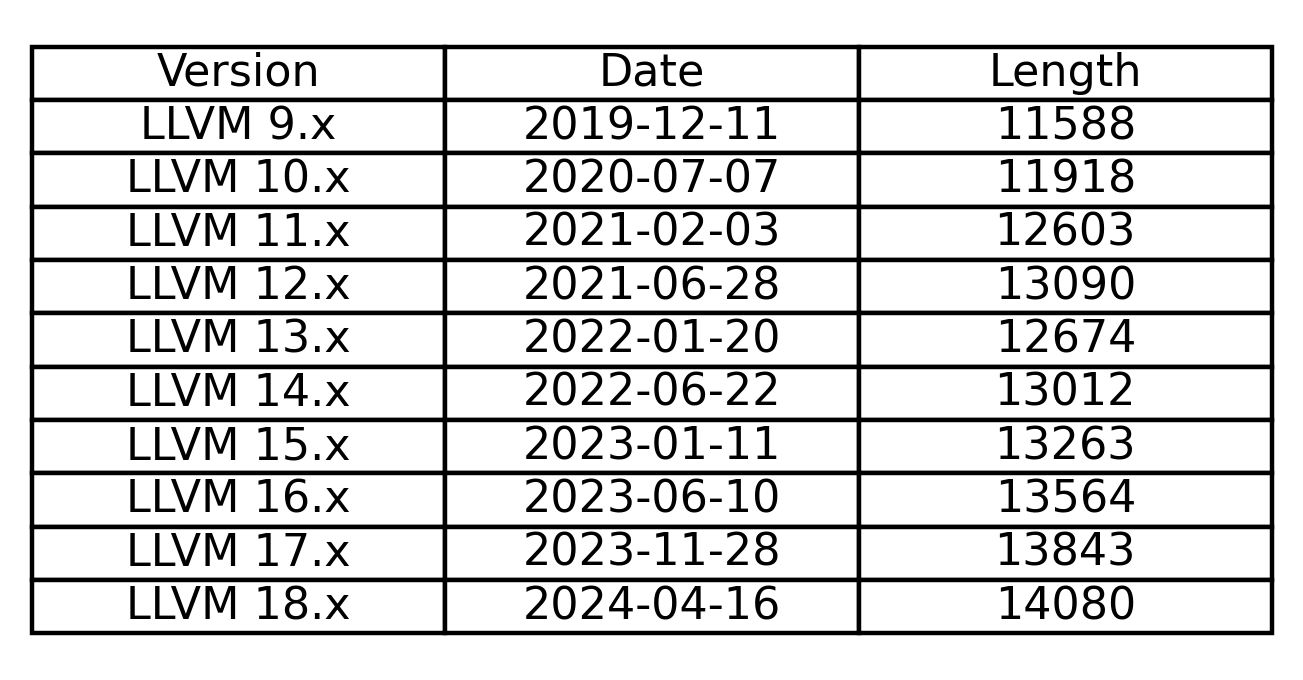

In [11]:
table_data = [[f"LLVM {version}.x", date, len(sequence)] for version, sequence, date in zip(versions, sequences, dates)]

# plot the table
plt.figure(figsize=(5, 2.5), dpi=320)
plt.axis('off')
plt.table(cellText=table_data,
          colLabels=['Version', 'Date', 'Length'],
          cellLoc='center',
          loc='center')
plt.savefig('out/llvm-versions.pdf', format='pdf', bbox_inches='tight')
plt.show()